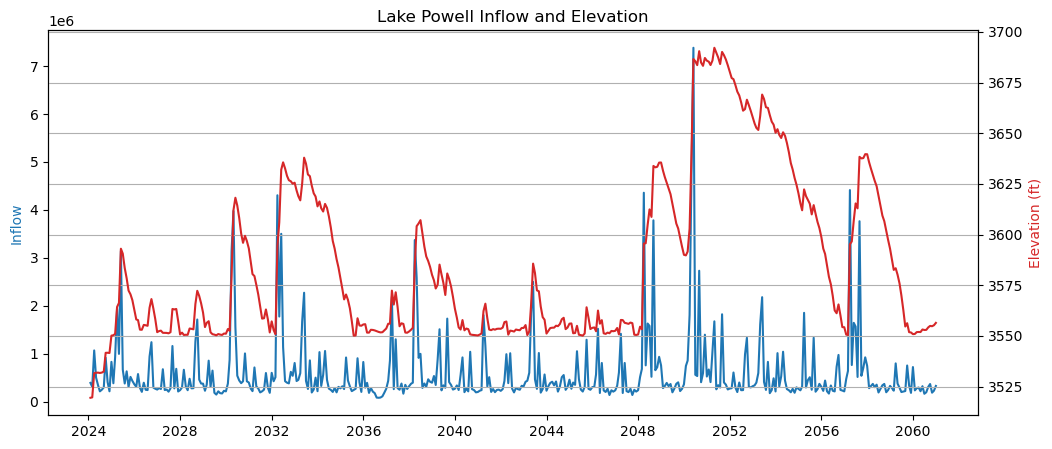

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. LOAD DATASETS

# Load Powell inflow + elevation time series
df = pd.read_excel("Powell level analysis.xlsx")

# Load Powell elevation–area–capacity table
elev_table = pd.read_csv("elevPowell.csv")



# 2. CLEAN + STANDARDIZE ELEVATION–STORAGE TABLE


elev_table = elev_table.rename(columns={
    "Elevation_ft_NAVD88": "elevation_ft",
    "Capacity_acrefeet": "storage_acft",
    "Area_acres": "area_acres"
})

elev_table = elev_table.sort_values("elevation_ft")



# 3. INTERPOLATION FUNCTIONS


def elev_to_storage(elev):
    """Convert elevation (ft) → storage (acre‑feet)."""
    return np.interp(
        elev,
        elev_table["elevation_ft"],
        elev_table["storage_acft"]
    )

def storage_to_elev(storage):
    """Convert storage (acre‑feet) → elevation (ft)."""
    return np.interp(
        storage,
        elev_table["storage_acft"],
        elev_table["elevation_ft"]
    )

def elev_to_area(elev):
    """Convert elevation (ft) → surface area (acres)."""
    return np.interp(
        elev,
        elev_table["elevation_ft"],
        elev_table["area_acres"]
    )



# 4. CLEAN THE POWELL INFLOW DATASET


df = df.rename(columns={"Unnamed: 0": "date"})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["Powell.Inflow"] = pd.to_numeric(df["Powell.Inflow"], errors="coerce")
df["Powell.EffectiveElevation"] = pd.to_numeric(df["Powell.EffectiveElevation"], errors="coerce")
df["Powell.EffectiveStorage"] = pd.to_numeric(df["Powell.EffectiveStorage"], errors="coerce")



# 5. ADD DERIVED INITIAL‑CONDITION FIELDS


df["storage_from_elev"] = elev_to_storage(df["Powell.EffectiveElevation"])
df["area_from_elev"] = elev_to_area(df["Powell.EffectiveElevation"])



# 6. EXTRACT THE ANALYSIS DATASET YOU WANT


analysis_df = df[[
    "date",
    "Powell.Inflow",
    "Powell.EffectiveElevation",
    "Powell.EffectiveStorage"
]].copy()



# 7. OPTIONAL: QUICK VISUAL CHECK

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df["date"], df["Powell.Inflow"], color="tab:blue")
ax1.set_ylabel("Inflow", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["Powell.EffectiveElevation"], color="tab:red")
ax2.set_ylabel("Elevation (ft)", color="tab:red")

plt.title("Lake Powell Inflow and Elevation")
plt.grid(True)
plt.show()


In [41]:

# 8. MASS BALANCE WITH 8.3 MAF/YR BASE RELEASE + 3500 RULE


# Base annual release target (acre-feet per year)
annual_release_acft = 8.3e6

# Convert to constant monthly release (acre-feet per month)
base_monthly_release = annual_release_acft / 12.0

# Create a new column for scenario outflow
df["Scenario.Outflow"] = np.nan

# Initialize scenario storage and elevation arrays
scenario_storage = np.zeros(len(df))
scenario_elev = np.zeros(len(df))


# Set starting elevation to 3525 ft
# Convert elevation → storage using your lookup table

scenario_elev[0] = 3525.0
scenario_storage[0] = elev_to_storage(3525.0)

for t in range(1, len(df)):

    # Previous timestep conditions
    prev_storage = scenario_storage[t-1]
    prev_elev = scenario_elev[t-1]
    Qin = df.loc[t-1, "Powell.Inflow"]

    
    # RULE:
    # If elevation < 3500 ft → release = 0.95 * inflow
    # Else → release = base monthly release (8.3 MAF/yr)
    if prev_elev < 3525:
        Qout = 0.95 * Qin
    else:
        Qout = base_monthly_release

    df.loc[t-1, "Scenario.Outflow"] = Qout

    # Mass balance
    scenario_storage[t] = prev_storage + Qin - Qout

    # Convert storage → elevation
    scenario_elev[t] = storage_to_elev(scenario_storage[t])

# Store results
df["Scenario.Storage"] = scenario_storage
df["Scenario.Elevation"] = scenario_elev


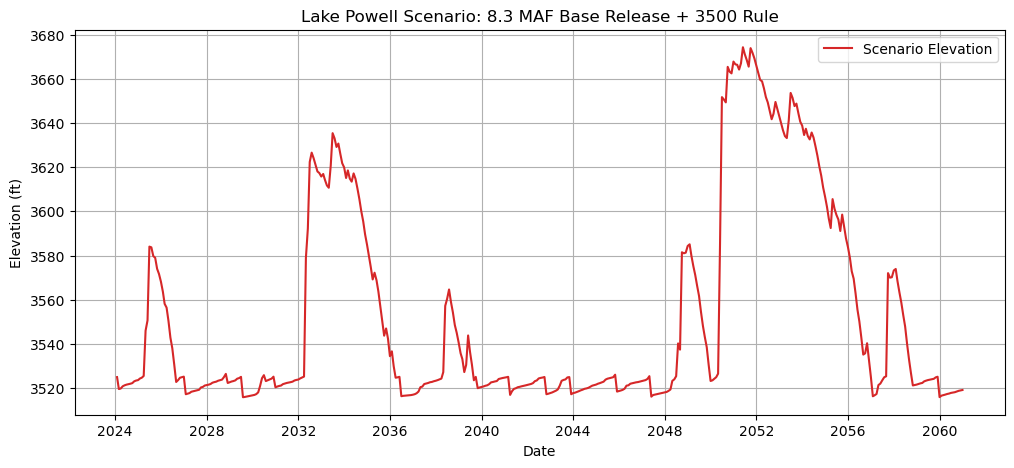

In [42]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df["date"], df["Scenario.Elevation"], label="Scenario Elevation", color="tab:red")
#ax.plot(df["date"], df["Powell.EffectiveElevation"], label="Observed Elevation", color="tab:blue")

ax.set_ylabel("Elevation (ft)")
ax.set_xlabel("Date")
ax.grid(True)
ax.legend()
plt.title("Lake Powell Scenario: 8.3 MAF Base Release + 3500 Rule")
plt.show()


In [43]:
# SCENARIO 2: RELEASE CAN ONLY CHANGE EVERY 6 MONTHS

df["Scenario2.Outflow"] = np.nan

scenario2_storage = np.zeros(len(df))
scenario2_elev = np.zeros(len(df))

# Start at elevation 3525 ft
scenario2_elev[0] = 3525.0
scenario2_storage[0] = elev_to_storage(3525.0)

# Memory variable for reduced-release mode
last_year_reduced = False

# Initialize current release at t=0
# Use the rule logic at the very first timestep
Qin0 = df.loc[0, "Powell.Inflow"]
if scenario2_elev[0] < 3525:
    current_release = 0.95 * Qin0
    reduced_this_year = True
else:
    current_release = base_monthly_release
    reduced_this_year = False

for t in range(1, len(df)):

    prev_storage = scenario2_storage[t-1]
    prev_elev = scenario2_elev[t-1]
    Qin = df.loc[t-1, "Powell.Inflow"]

    # Determine if we are at the start of a 6-month block
    # Blocks: Jan–Jun (months 1–6), Jul–Dec (months 7–12)
    month = df.loc[t, "date"].month
    is_block_start = (month == 1) or (month == 7)

    if is_block_start:

        # APPLY RULES ONLY AT BLOCK START
        if prev_elev < 3525:
            current_release = 0.95 * Qin
            reduced_this_year = True

        elif last_year_reduced and prev_elev < 3525:
            current_release = 0.95 * Qin
            reduced_this_year = True

        else:
            current_release = base_monthly_release
            reduced_this_year = False


    # Use the locked-in release for this month

    Qout = current_release
    df.loc[t-1, "Scenario2.Outflow"] = Qout

    # Mass balance
    scenario2_storage[t] = prev_storage + Qin - Qout

    # Convert storage → elevation
    scenario2_elev[t] = storage_to_elev(scenario2_storage[t])


    # Update memory at year boundaries

    if month == 12:
        last_year_reduced = reduced_this_year

df["Scenario2.Storage"] = scenario2_storage
df["Scenario2.Elevation"] = scenario2_elev


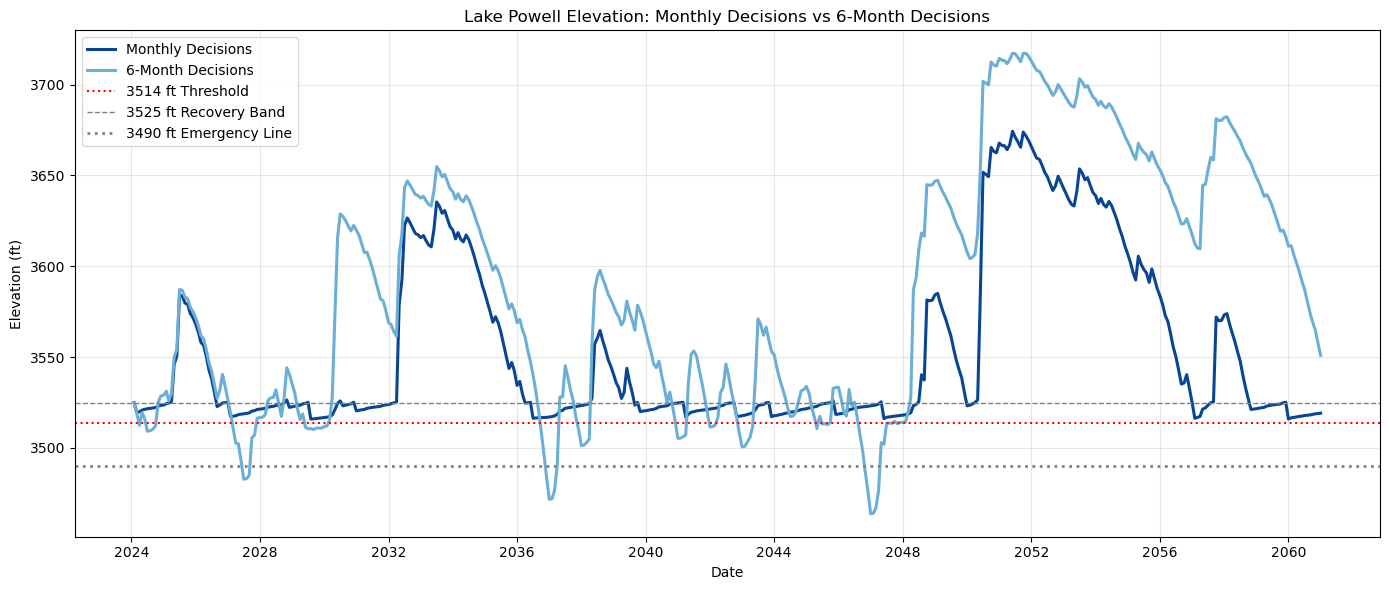

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Scenario 1 (monthly decisions)
plt.plot(df["date"], df["Scenario.Elevation"],
         label="Monthly Decisions",
         color="#084594", linewidth=2.2)   # dark blue

# Scenario 2 (6‑month decisions)
plt.plot(df["date"], df["Scenario2.Elevation"],
         label="6‑Month Decisions",
         color="#6baed6", linewidth=2.2)  # lighter blue

# Threshold lines
plt.axhline(3514, color="red", linestyle=":", linewidth=1.5, label="3514 ft Threshold")
plt.axhline(3525, color="gray", linestyle="--", linewidth=1.0, label="3525 ft Recovery Band")

# NEW: 3490 ft emergency line
plt.axhline(3490, color="gray", linestyle=":", linewidth=2.0, label="3490 ft Emergency Line")

plt.title("Lake Powell Elevation: Monthly Decisions vs 6‑Month Decisions")
plt.xlabel("Date")
plt.ylabel("Elevation (ft)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
# SCENARIO 3: RELEASE DECISION ONCE PER YEAR (ANNUAL LOCK)

df["Scenario3.Outflow"] = np.nan

scenario3_storage = np.zeros(len(df))
scenario3_elev = np.zeros(len(df))

# Start at elevation 3525 ft
scenario3_elev[0] = 3525.0
scenario3_storage[0] = elev_to_storage(3525.0)

# Memory variable for reduced-release mode
last_year_reduced = False

# Initialize current release at t=0 using rule logic
Qin0 = df.loc[0, "Powell.Inflow"]
if scenario3_elev[0] < 3525:
    current_release = 0.95 * Qin0
    reduced_this_year = True
else:
    current_release = base_monthly_release
    reduced_this_year = False

current_year = df.loc[0, "date"].year

for t in range(1, len(df)):

    prev_storage = scenario3_storage[t-1]
    prev_elev = scenario3_elev[t-1]
    Qin = df.loc[t-1, "Powell.Inflow"]
    year = df.loc[t, "date"].year


    # At the start of a new year, update the release decision

    if year != current_year:
        current_year = year

        if prev_elev < 3525:
            current_release = 0.95 * Qin
            reduced_this_year = True

        elif last_year_reduced and prev_elev < 3550:
            current_release = 0.95 * Qin
            reduced_this_year = True

        else:
            current_release = base_monthly_release
            reduced_this_year = False

    # Use the locked-in annual release
    Qout = current_release
    df.loc[t-1, "Scenario3.Outflow"] = Qout

    # Mass balance
    scenario3_storage[t] = prev_storage + Qin - Qout

    # Convert storage → elevation
    scenario3_elev[t] = storage_to_elev(scenario3_storage[t])

    # At end of year, update memory
    if df.loc[t, "date"].month == 12:
        last_year_reduced = reduced_this_year

df["Scenario3.Storage"] = scenario3_storage
df["Scenario3.Elevation"] = scenario3_elev


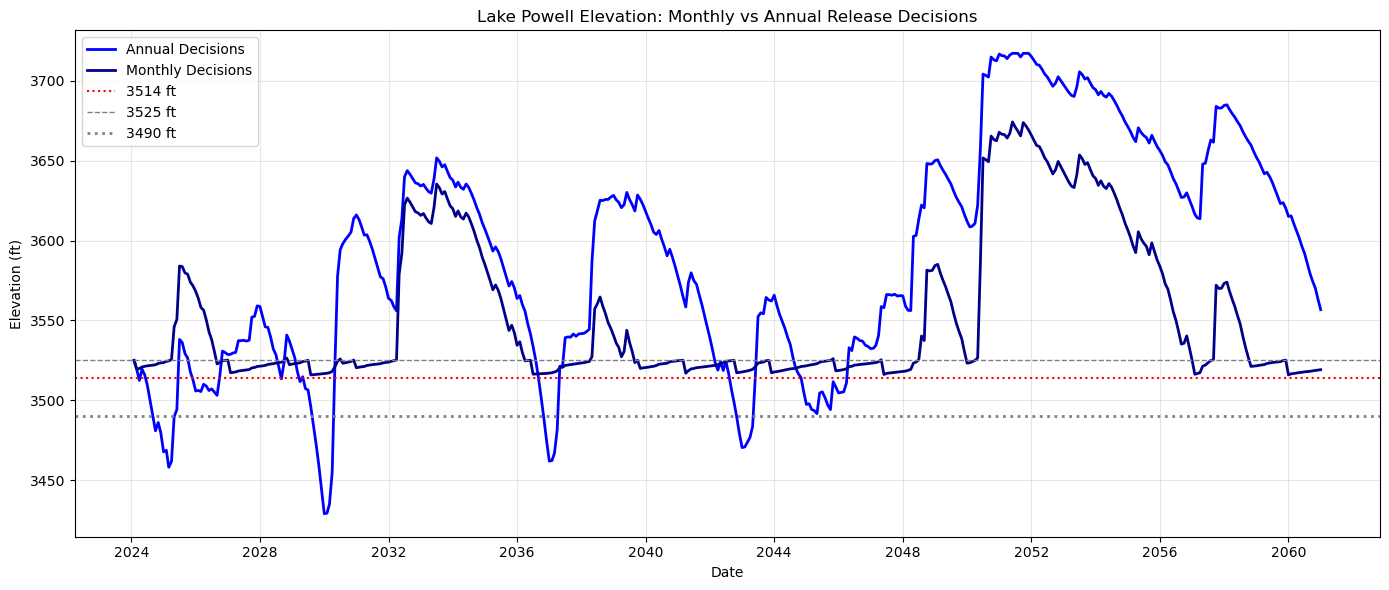

In [46]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["Scenario3.Elevation"],
         label="Annual Decisions",
         color="blue", linewidth=2.0)


# plt.plot(df["date"], df["Scenario2.Elevation"],
#          label="Scenario 2 (6-Month Decisions)",
#          color="blue", linewidth=2.0)

plt.plot(df["date"], df["Scenario.Elevation"],
         label="Monthly Decisions",
         color="darkblue", linewidth=2.0)

plt.axhline(3514, color="red", linestyle=":", linewidth=1.5, label="3514 ft")
plt.axhline(3525, color="gray", linestyle="--", linewidth=1.0, label="3525 ft")
plt.axhline(3490, color="gray", linestyle=":", linewidth=2.0, label="3490 ft")

plt.title("Lake Powell Elevation: Monthly vs Annual Release Decisions")
plt.xlabel("Date")
plt.ylabel("Elevation (ft)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
